In [6]:
import sys
sys.path.append("../src")

from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from config import TRAIN_DIR, TEST_DIR, CLASSES

In [2]:
TRAIN_DIR, TEST_DIR

(PosixPath('/Users/krishivshah/Documents/brain-tumor-mri-classification/data/Training'),
 PosixPath('/Users/krishivshah/Documents/brain-tumor-mri-classification/data/Testing'))

In [4]:
def count_images(directory):
    counts = {}

    for cls in CLASSES:
        cls_path = directory / cls

        counts[cls] = len([
            f for f in cls_path.iterdir()
            if f.suffix.lower() in [".jpg", ".jpeg", ".png"]
        ])
    
    return counts


train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)

train_counts, test_counts

({'glioma': 1400, 'meningioma': 1400, 'notumor': 1400, 'pituitary': 1400},
 {'glioma': 400, 'meningioma': 400, 'notumor': 400, 'pituitary': 400})

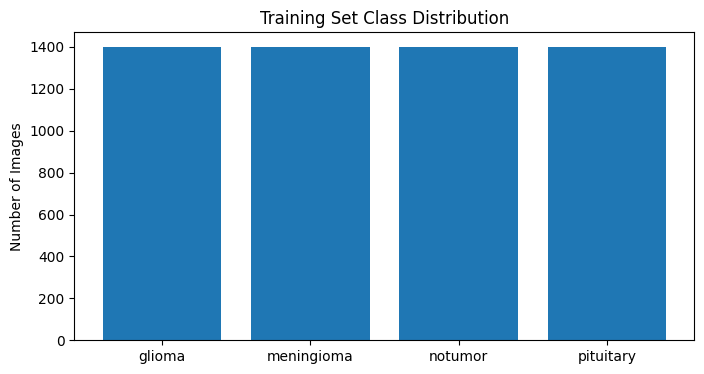

In [7]:
plt.figure(figsize=(8, 4))

plt.bar(train_counts.keys(), train_counts.values())

plt.title("Training Set Class Distribution")
plt.ylabel("Number of Images")

plt.show()

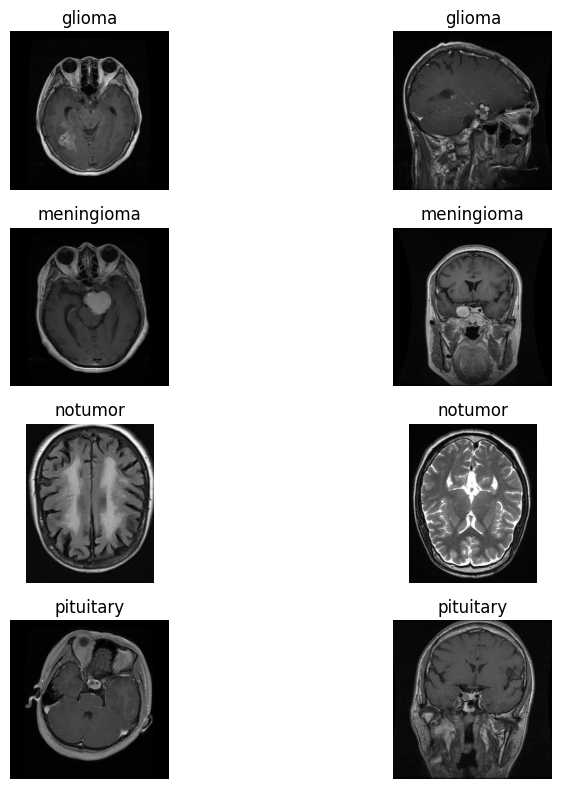

In [8]:
def show_samples(directory, n=2):
    plt.figure(figsize=(10,8))

    idx = 1

    for cls in CLASSES:
        cls_path = directory / cls

        images = list(cls_path.iterdir())[:n]

        for img_path in images:
            img = Image.open(img_path)

            plt.subplot(len(CLASSES), n, idx)

            plt.imshow(img, cmap="gray")
            plt.title(cls)

            plt.axis("off")

            idx += 1
    
    plt.tight_layout()
    plt.show()


show_samples(TRAIN_DIR, n=2)

In [9]:
sizes = []

for cls in CLASSES:
    cls_path = TRAIN_DIR / cls

    for img_path in list(cls_path.iterdir())[:20]:
        img = Image.open(img_path)

        sizes.append(img.size)

Counter(sizes)

Counter({(512, 512): 57,
         (225, 225): 5,
         (630, 630): 4,
         (441, 427): 1,
         (201, 251): 1,
         (359, 449): 1,
         (235, 228): 1,
         (232, 217): 1,
         (230, 282): 1,
         (196, 257): 1,
         (755, 824): 1,
         (200, 252): 1,
         (227, 300): 1,
         (600, 600): 1,
         (206, 244): 1,
         (227, 262): 1,
         (1338, 1304): 1})